In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
manyscan=1 # want to plot ~10 scans around the good-seeing scan
line=0 # this is just an index for Ca II H. In the .py file I used for the clustering, this is 1 if H-beta.  Don't worry about this key...
n_clusters0=35 # number of clusters
colors = plt.cm.turbo(np.linspace(0,1,n_clusters0)) #colormap for plotting

# define indices bounding the lines we could cluster
hbeta_low =353
hbeta_high = 640
caII_low = 480 #570 for first calibration pre March 6
caII_high = 690
hepsilon_low = 685
hepsilon_high = 810

#cutoff0 = 1.5 # for more than one frame
if line == 1:
    cutoff0=9 # for h-beta
    if manyscan:
        cutoff0=4
if line == 0: # for ca II
    cutoff0=2.5
    if manyscan:
        cutoff0=2.5 

# number of clusters
if line == 1:
    n_clusters0 = 35 # 10 works for hbeta, 6 for Ca II H seems to be all that's needed, 6 also for h-ep
if line == 0:
    n_clusters0 = 35

#spatial limits (along slit) of ribbon -different for arms 1 and 2
if line == 1:
    startspace = 300 
    endspace = 1800 
if line == 0:
    startspace = 300 
    endspace = 1700
    
# define rest wavelengths
if line == 1:
    cent= 486.1375
if line == 0:
    cent = 396.85
    
# define limits of line; essentially the blue and red bounds of spectral range to cluster
if line == 1:
    linelow = hbeta_low
    linehigh = hbeta_high
if line == 0:
    linelow = caII_low
    linehigh = caII_high

# function to convert observed wavelength to velocity
def find_velocity(rest_wl,obs_wl):
    c= 299792458 # m/s
    
    return c*(obs_wl-rest_wl)/(obs_wl)

base = '/Users/coletamburri/Desktop/' # change to directory you need

In [15]:
#load clustering file
km_file = np.load(base+'kmeans_CaIIH_ninit100.npz',allow_pickle='True')

#extract variables from clustering file
xarr_ch=km_file['xarr_ch'] # x coordinates for pcolormesh
yarr_ch=km_file['yarr_ch'] # y coordinates for pcolormesh
frame_line=km_file['frame_line'] # scans of interest, with along-slit direction limited just to what we want to see
normprofiles_line=km_file['normprofiles_line'] # normalized spectral line profiles
times=km_file['times'] # times for each ViSP slit position
km01=km_file['km0'] # numpy array containing the KMeansClusterer object (nltk)
labels0=km_file['labels0'] # numpy array containing the cluster number for each pixel
wave=km_file['wave'] # wavelength array for chosen arm
sortedinds=km_file['sortedinds'] # cluster indices sorted by weighted mean (blueshifted to redshifted
selwls=km_file['selwls'] # wavelength array for chosen line only
sortedwls=km_file['sortedwls'] # location of calculated line center (0 is the first index in "selwls")

#read pandas dataframe containing clusters from csv
# contains the mask info, including the x values, y values, and cluster number corresponding to each pixel
df_mask = pd.read_csv(base+'kmeans_CaIIH_ninit100_df.csv') 

##the result of kmeans is a weird class from the nltk package; extract the necessary info with this line
#km0 = km01.item()   # extract the object so we can read variables directly as attributes of the class

cc = km0.cluster_centers_

In [16]:
km0

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",35
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",100
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](35, 210)"

In [17]:
df_mask

,Unnamed: 0,x,y,dist
0,0,8,1161,5
1,1,8,1162,5
2,2,8,1163,5
3,3,8,1164,5
4,4,8,1165,5
...,...,...,...,...
296825,296825,907,950,16
296826,296826,907,951,16
296827,296827,907,952,16
296828,296828,907,953,16


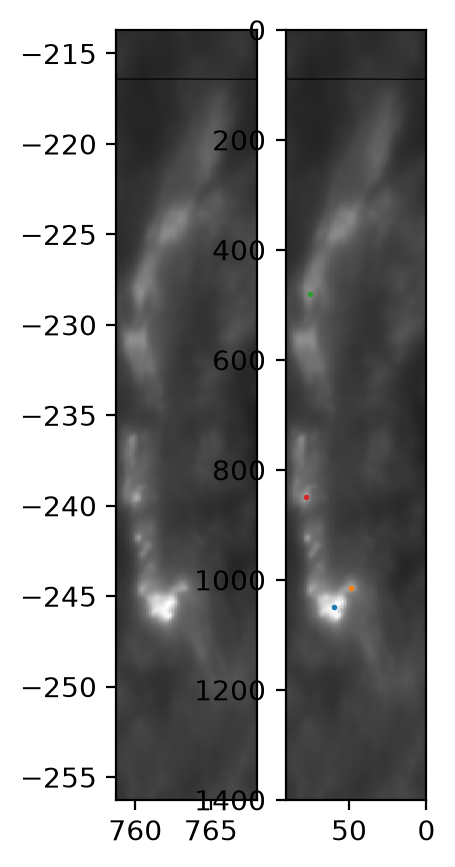

In [18]:
fig,ax=plt.subplots(1,2,dpi=200,figsize=(2,5))
axes=ax.flatten()
axes[0].pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].pcolormesh(np.transpose(frame_line[(91):(91*(1+1)),:]),cmap='grey',alpha=1)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
# axes[1].set_xticks([])
# axes[1].set_yticks([])
axes[1].scatter(60,1050,1)
axes[1].scatter(49,1015,1)
axes[1].scatter(75,480,1)
axes[1].scatter(78,850,1)

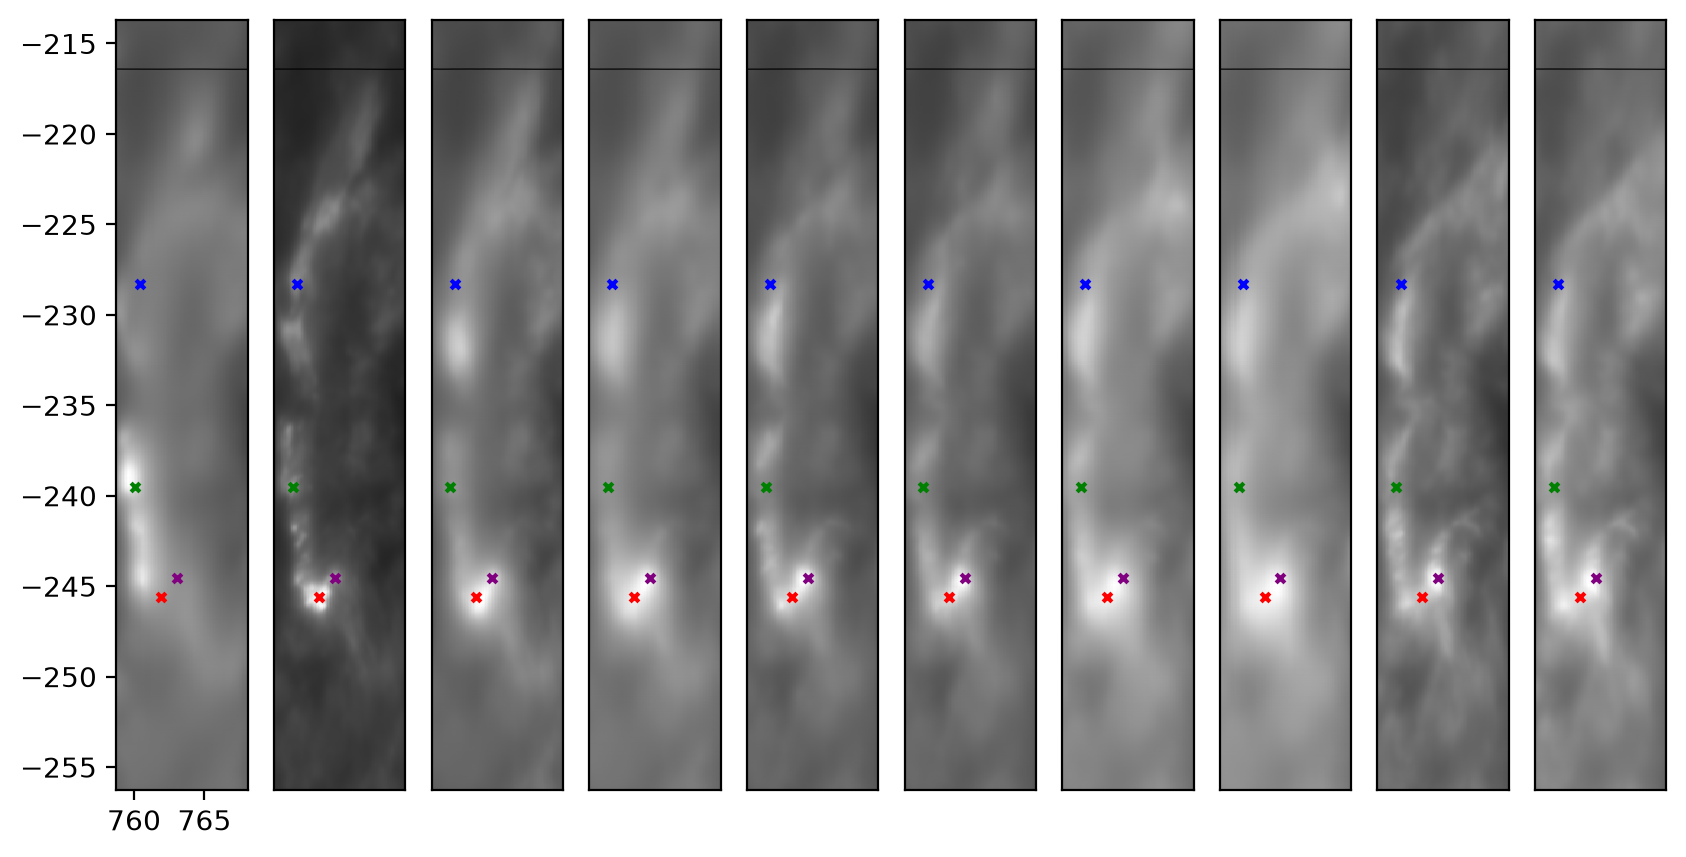

In [19]:
fig,ax=plt.subplots(1,10,dpi=200,figsize=(10,5))
axes=ax.flatten()
for i in range(10):
    axes[i].pcolormesh(xarr_ch,yarr_ch,np.transpose(frame_line[(91*i):(91*(i+1)),:]),cmap='grey',alpha=1)
    axes[i].scatter(xarr_ch[60],yarr_ch[1050],c='red',marker='x',s=10)
    axes[i].scatter(xarr_ch[49],yarr_ch[1015],c='purple',marker='x',s=10)
    axes[i].scatter(xarr_ch[75],yarr_ch[480],c='blue',marker='x',s=10)
    axes[i].scatter(xarr_ch[78],yarr_ch[850],c='green',marker='x',s=10)



    if i>0:
        axes[i].set_xticks([])
        axes[i].set_yticks([])



In [20]:
#find nearest location in dataframe for these coordinates
x=60
y=1050

pixkm = []
for i in range(10):
    mask = (df_mask['x'] == 60+(91*i)) & (df_mask['y'] == 1050)
    print(int(df_mask[mask]['dist'].item()))
    pixkm.append(int(df_mask[mask]['dist'].item()))

19
34
30
26
26
26
19
19
19
19


In [21]:
#find nearest location in dataframe for these coordinates
x=49
y=1015

pixkm1 = []
for i in range(10):
    mask = (df_mask['x'] == x+(91*i)) & (df_mask['y'] == y)
    print(int(df_mask[mask]['dist'].item()))
    pixkm1.append(int(df_mask[mask]['dist'].item()))

15
30
26
26
31
26
19
19
31
19


In [22]:
#find nearest location in dataframe for these coordinates
x=75
y=480

pixkm2 = []
for i in range(10):
    mask = (df_mask['x'] == x+(91*i)) & (df_mask['y'] == y)
    if len(df_mask[mask])>0:
        print(int(df_mask[mask]['dist'].item()))
        pixkm2.append(int(df_mask[mask]['dist'].item()))
    else:
        pixkm2.append('none')


0
2
7
9
9
9
9
15


In [23]:
#find nearest location in dataframe for these coordinates
x=78
y=850

pixkm3 = []
for i in range(10):
    mask = (df_mask['x'] == x+(91*i)) & (df_mask['y'] == y)
    if len(df_mask[mask])>0:
        print(int(df_mask[mask]['dist'].item()))
        pixkm3.append(int(df_mask[mask]['dist'].item()))
    else:
        pixkm3.append('none')


34
34
27
23
23
14
14
23
14
14


In [24]:
#make arr of necessary
arr_ev_pix = []
for i in range(len(pixkm)):
    arr_ev_pix.append(cc[sortedinds[pixkm[i]]])

arr_ev_pix1 = []
for i in range(len(pixkm1)):
    arr_ev_pix1.append(cc[sortedinds[pixkm1[i]]])

arr_ev_pix2 = []
for i in range(len(pixkm2)):
    if pixkm2[i] is not 'none':
        arr_ev_pix2.append(cc[sortedinds[pixkm2[i]]])
    else:
        arr_ev_pix2.append(np.zeros(len(selwls)))

arr_ev_pix3 = []
for i in range(len(pixkm3)):
    if pixkm3[i] is not 'none':
        arr_ev_pix3.append(cc[sortedinds[pixkm3[i]]])
    else:
        arr_ev_pix3.append(np.zeros(len(selwls)))

<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:19: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:19: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/var/folders/zv/_lmn_hx54rx33p0kc27kzf780000gn/T/ipykernel_64977/3151427182.py:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if pixkm2[i] is not 'none':
/var/folders/zv/_lmn_hx54rx33p0kc27kzf780000gn/T/ipykernel_64977/3151427182.py:19: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if pixkm3[i] is not 'none':


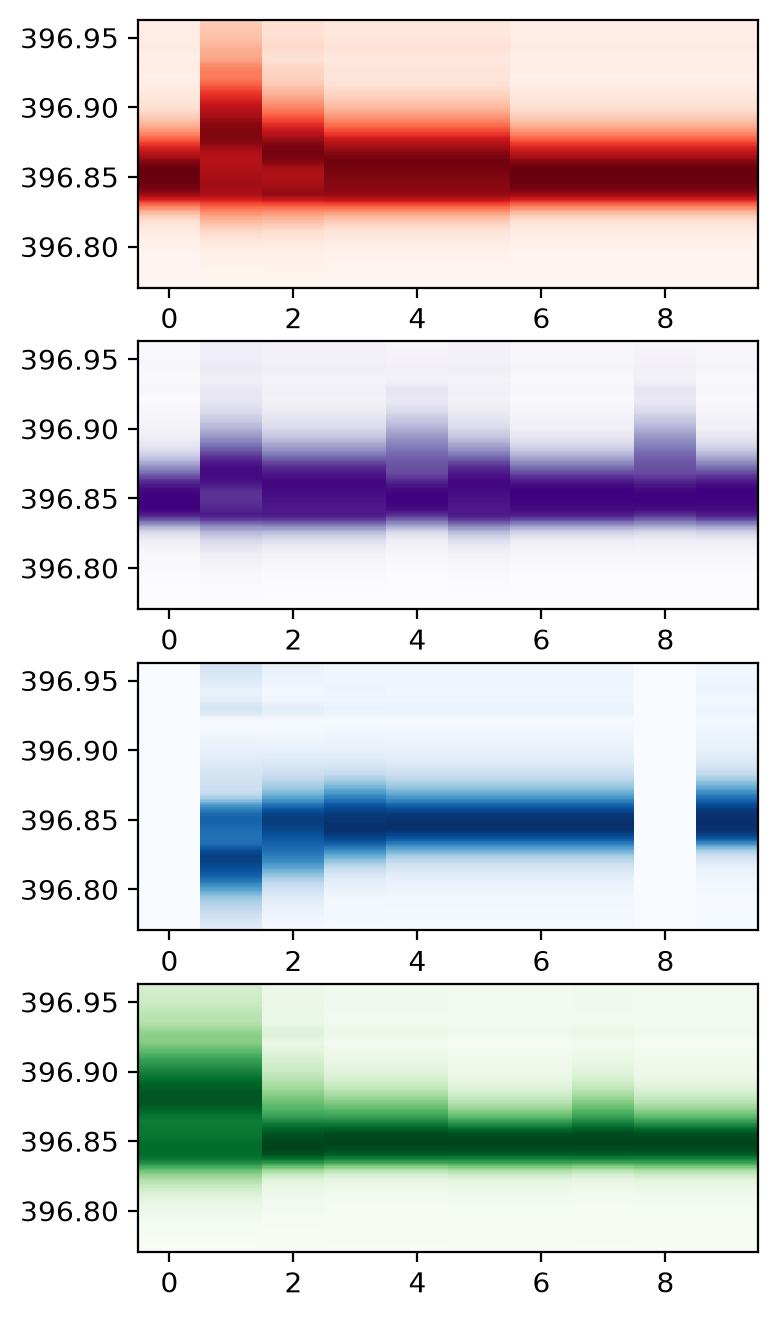

In [25]:
fig,ax=plt.subplots(4,1,dpi=200,figsize=(4,8))
axes=ax.flatten()
ax[0].pcolormesh(np.arange(10),selwls,np.transpose(arr_ev_pix),cmap='Reds')
ax[1].pcolormesh(np.arange(10),selwls,np.transpose(arr_ev_pix1),cmap='Purples')
ax[2].pcolormesh(np.arange(10),selwls,np.transpose(arr_ev_pix2),cmap='Blues')
ax[3].pcolormesh(np.arange(10),selwls,np.transpose(arr_ev_pix3),cmap='Greens')

In [60]:
labels0

array([3, 3, 3, ..., 1, 1, 1], dtype=int32)

In [62]:
cc=km0.cluster_centers_

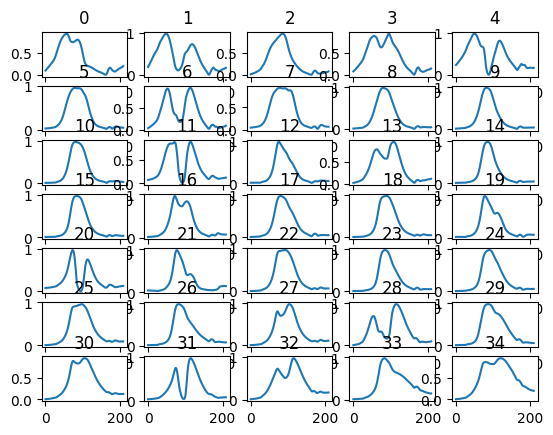

In [68]:
fig,ax=plt.subplots(7,5)
axes=ax.flatten()
for i in range(len(cc)):
    axes[i].plot(cc[sortedinds[i]])
    axes[i].set_title(i)

In [65]:
len(cc)

35